# OpenIE-PT — Experimento Final

Notebook consolidado do projeto. Reproduz, do zero, todo o experimento que
alimenta o artigo: baseline, ablações sistemáticas, análise de regimes de
avaliação, análise de erros e análise do módulo de atenção.

## Estrutura

- **Parte 0** — Visão geral e questões de pesquisa (esta seção)
- **Parte 1** — Setup (imports, paths, helper de execução com cache)
- **Parte 2** — Smoke test (validação rápida do pipeline)
- **Parte 3** — Ablações (RQ1..RQ8) e consolidação
- **Parte 4** — Análises derivadas sobre o melhor run
- **Parte 5** — Tabelas finais para o paper
- **Parte 6** — Síntese

## Questões de pesquisa

- **RQ1** — Qual o F1 de um baseline UD puro (sem atenção, sem regras teóricas)?
- **RQ2** — Qual a contribuição da extração copular? (`full` × `restricted` × `off`)
- **RQ3** — Qual a contribuição da atenção (BERTimbau)? (`off` × `on thr=0.0` × `on thr=0.15`)
- **RQ4** — Qual a contribuição agregada das regras teóricas?
- **RQ5** — Se a teoria afeta o F1, qual grupo é responsável? (só E × só S)
- **RQ6** — Dentro do grupo problemático, qual regra individual é a culpada?
- **RQ7** — Quais padrões UD concentram os erros?
- **RQ8** — Os ganhos dos componentes são aditivos na melhor configuração combinada?

## Tempo estimado de execução

Primeira execução: ~30 min (todas as 27 ablações + análises).
Reexecuções: ~5 min (graças ao cache por disco).

## Como usar

1. Ajustar os caminhos na Parte 1.
2. Rodar o notebook de cima para baixo.
3. O CSV consolidado é salvo em `./ablation_experiments/ablation_results.csv`.
4. As tabelas da Parte 5 estão prontas para colar no paper.

---

# Parte 1 — Setup

## 1.1 Imports

In [2]:
from pathlib import Path
import json
import traceback
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from openie_v11_bia_theoretical_experiment_selfcontained_patched import (
    Config, OpenIEExtractorBIA, run_experiment
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 200)
print("Imports OK")

Imports OK


## 1.2 Caminhos

Tudo que precisa ser ajustado em diferentes máquinas está concentrado aqui.

In [3]:
# ------------------------------------------------------------
# Arquivos de entrada
# ------------------------------------------------------------
GOLD_PATH   = "bia_gold_sentences.jsonl"
BOSQUE_PATH = "pt_bosque-ud-train.conllu"

# ------------------------------------------------------------
# Diretório de saída (cada ablação gera uma subpasta aqui)
# ------------------------------------------------------------
OUT_BASE = Path("./ablation_experiments")
OUT_BASE.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Run-alvo para as análises derivadas (Parte 4)
# Use o label da ablação que melhor representa o sistema final.
# Conforme o estudo: "UD + atenção, sem teoria" (rq3_attn_on_thr0) é a melhor.
# ------------------------------------------------------------
TARGET_RUN_LABEL = "rq3_attn_on_thr0"

print("GOLD_PATH        =", GOLD_PATH)
print("BOSQUE_PATH      =", BOSQUE_PATH)
print("OUT_BASE         =", OUT_BASE.resolve())
print("TARGET_RUN_LABEL =", TARGET_RUN_LABEL)

GOLD_PATH        = bia_gold_sentences.jsonl
BOSQUE_PATH      = pt_bosque-ud-train.conllu
OUT_BASE         = /home/ricardo/doutorado/extrator/v15/ablation_experiments
TARGET_RUN_LABEL = rq3_attn_on_thr0


## 1.3 Helper de execução com cache

`run_ablation(cfg, label)` é o núcleo do notebook. Executa o experimento, salva em
pasta isolada, lê métricas e apenda em `RESULTS`. **Se o metrics.json já existir,
pula a execução e lê do disco** — o que torna reexecuções rápidas e permite
congelar resultados.

In [4]:
RESULTS = []  # acumulador global (uma dict-row por ablação)

def _cfg_signature(cfg):
    """Captura flags relevantes da config para a linha consolidada."""
    keys = [
        "no_attn", "theory_mode", "apply_theoretical_rules",
        "cop_mode", "extract_cop", "attn_threshold",
        "attn_decision_enabled", "attn_rerank_enabled",
        "heads_mode", "top_k_heads",
    ]
    return {k: getattr(cfg, k, None) for k in keys}


def run_ablation(cfg, label, force_rerun=False, verbose=True):
    """
    Executa run_experiment e apenda uma linha em RESULTS.
    Se metrics.json já existe em disco e force_rerun=False, lê direto (cache).
    """
    out_dir = OUT_BASE / f"abl_{label}"
    out_dir.mkdir(parents=True, exist_ok=True)
    dataset_name = f"bia_abl_{label}"
    metrics_path = out_dir / f"{dataset_name}_metrics.json"

    row = {
        "label":        label,
        "status":       None,
        "tp":           None,
        "fp":           None,
        "fn":           None,
        "precision":    None,
        "recall":       None,
        "f1":           None,
        "metrics_path": str(metrics_path),
        "error":        None,
        "source":       None,
        **_cfg_signature(cfg),
    }

    # Caminho A: cache — já existe em disco
    if metrics_path.exists() and not force_rerun:
        try:
            m = json.loads(metrics_path.read_text(encoding="utf-8"))
            row.update({
                "status":    "cached",
                "tp":        m.get("TP", m.get("tp")),
                "fp":        m.get("FP", m.get("fp")),
                "fn":        m.get("FN", m.get("fn")),
                "precision": m.get("precision"),
                "recall":    m.get("recall"),
                "f1":        m.get("f1"),
                "source":    "disk",
            })
            if verbose:
                print(f"[CACHE] {label:35s}  F1={row['f1']:.4f}  P={row['precision']:.4f}  R={row['recall']:.4f}")
            RESULTS.append(row)
            return row
        except Exception as e:
            if verbose:
                print(f"[WARN] cache corrompido em {label}: {e}. Vou re-executar.")

    # Caminho B: executa
    if verbose:
        print(f"\n{'='*70}\n  Executando: {label}\n{'='*70}")
        for k, v in _cfg_signature(cfg).items():
            print(f"  {k:30s} = {v}")

    try:
        results = run_experiment(
            config=cfg,
            gold_path=GOLD_PATH,
            output_dir=str(out_dir),
            dataset_name=dataset_name,
        )
        m = results.get("metrics", {})
        row.update({
            "status":    "ok",
            "tp":        m.get("TP", m.get("tp")),
            "fp":        m.get("FP", m.get("fp")),
            "fn":        m.get("FN", m.get("fn")),
            "precision": m.get("precision"),
            "recall":    m.get("recall"),
            "f1":        m.get("f1"),
            "source":    "fresh",
        })
        if verbose:
            print(f"  -> F1={row['f1']:.4f}  P={row['precision']:.4f}  R={row['recall']:.4f}"
                  f"  TP/FP/FN={row['tp']}/{row['fp']}/{row['fn']}")

    except Exception as e:
        row["status"] = f"error: {type(e).__name__}"
        row["error"]  = str(e)[:300]
        if verbose:
            print(f"  ERRO: {row['status']}")
            traceback.print_exc()

    RESULTS.append(row)
    return row

print("run_ablation() definido. RESULTS inicializado (len=0).")

run_ablation() definido. RESULTS inicializado (len=0).


---

# Parte 2 — Smoke test

Sanity-check com uma sentença. Confirma que o pipeline carrega, o parser roda e
triplas são geradas. Se esta célula falhar, todo o resto falhará — aborte aqui e
corrija antes de seguir.

In [5]:
_cfg_smoke = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,
    no_attn=True,
    theory_mode="off",
    apply_theoretical_rules=False,
    cop_mode="full",
)
_extractor = OpenIEExtractorBIA(_cfg_smoke)

_test_sent = "Daniela comeu maçã e pêra no lanche da tarde."
_rows, _ud = _extractor.extract(_test_sent)

if _rows:
    _df = pd.DataFrame(_rows)
    print(f"Extraídas {len(_df)} triplas:")
    display(_df[["arg1", "rel", "arg2", "pattern_ud"]])
else:
    print("Sem extrações.")

del _extractor  # libera GPU

🔄 Carregando Stanza...
✅ OpenIE-PT BIA-aligned inicializado


Extraídas 2 triplas:


,arg1,rel,arg2,pattern_ud
0,Daniela,comeu,maçã,verb+obj[coord]
1,Daniela,comeu,pêra,verb+obj[coord]


---

# Parte 3 — Ablações sistemáticas

Cada ablação parte do **mesmo baseline de referência** (UD puro, sem atenção,
sem teoria, cópula `full`) e altera **uma variável por vez**. Convenções:

- `Config(...)` define os parâmetros.
- `run_ablation(cfg, label="rqX_nome")` executa ou lê do cache.
- Todas as execuções apendam linhas em `RESULTS`.

## 3.1 RQ1 — Baseline UD puro

Extração 100% baseada em padrões UD. Sem atenção, sem teoria. É a **referência
para todos os Δ F1** do paper.

In [5]:
cfg_baseline = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,
    no_attn=True,
    theory_mode="off",
    apply_theoretical_rules=False,
    cop_mode="full",
)
run_ablation(cfg_baseline, label="rq1_baseline_ud_puro")

🔄 Carregando Stanza...



  Executando: rq1_baseline_ud_puro
  no_attn                        = True
  theory_mode                    = off
  apply_theoretical_rules        = False
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


✅ OpenIE-PT BIA-aligned inicializado


Extraindo triplas [bia_abl_rq1_baseline_ud_puro]:   0%|          | 0/262 [00:00<?, ?sent/s]

  -> F1=0.5271  P=0.4496  R=0.6370  TP/FP/FN=272/333/155


{'label': 'rq1_baseline_ud_puro',
 'status': 'ok',
 'tp': 272,
 'fp': 333,
 'fn': 155,
 'precision': 0.44958677685950416,
 'recall': 0.6370023419203747,
 'f1': 0.5271317829457365,
 'metrics_path': 'ablation_experiments/abl_rq1_baseline_ud_puro/bia_abl_rq1_baseline_ud_puro_metrics.json',
 'error': None,
 'source': 'fresh',
 'no_attn': True,
 'theory_mode': 'off',
 'apply_theoretical_rules': False,
 'cop_mode': 'full',
 'extract_cop': True,
 'attn_threshold': 0.0,
 'attn_decision_enabled': True,
 'attn_rerank_enabled': True,
 'heads_mode': 'rank',
 'top_k_heads': 10}

## 3.2 RQ2 — Cópula (cop_mode)

Varia apenas `cop_mode` sobre o baseline.

In [6]:
# 2a. cop_mode="full" (referência, igual ao baseline)
cfg_cop_full = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,
    no_attn=True,
    theory_mode="off",
    apply_theoretical_rules=False,
    cop_mode="full",
)
run_ablation(cfg_cop_full, label="rq2_cop_full")

# 2b. cop_mode="restricted"
cfg_cop_restricted = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,
    no_attn=True,
    theory_mode="off",
    apply_theoretical_rules=False,
    cop_mode="restricted",
)
run_ablation(cfg_cop_restricted, label="rq2_cop_restricted")

# 2c. cop_mode="off" + extract_cop=False
cfg_cop_off = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,
    no_attn=True,
    theory_mode="off",
    apply_theoretical_rules=False,
    cop_mode="off",
    extract_cop=False,
)
run_ablation(cfg_cop_off, label="rq2_cop_off")

🔄 Carregando Stanza...



  Executando: rq2_cop_full
  no_attn                        = True
  theory_mode                    = off
  apply_theoretical_rules        = False
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


✅ OpenIE-PT BIA-aligned inicializado


Extraindo triplas [bia_abl_rq2_cop_full]:   0%|          | 0/262 [00:00<?, ?sent/s]

🔄 Carregando Stanza...


...

  -> F1=0.4756  P=0.4524  R=0.5012  TP/FP/FN=214/259/213

  Executando: rq2_cop_off
  no_attn                        = True
  theory_mode                    = off
  apply_theoretical_rules        = False
  cop_mode                       = off
  extract_cop                    = False
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


✅ OpenIE-PT BIA-aligned inicializado


Extraindo triplas [bia_abl_rq2_cop_off]:   0%|          | 0/262 [00:00<?, ?sent/s]

  -> F1=0.4743  P=0.4540  R=0.4965  TP/FP/FN=212/255/215


{'label': 'rq2_cop_off',
 'status': 'ok',
 'tp': 212,
 'fp': 255,
 'fn': 215,
 'precision': 0.4539614561027837,
 'recall': 0.4964871194379391,
 'f1': 0.4742729306487696,
 'metrics_path': 'ablation_experiments/abl_rq2_cop_off/bia_abl_rq2_cop_off_metrics.json',
 'error': None,
 'source': 'fresh',
 'no_attn': True,
 'theory_mode': 'off',
 'apply_theoretical_rules': False,
 'cop_mode': 'off',
 'extract_cop': False,
 'attn_threshold': 0.0,
 'attn_decision_enabled': True,
 'attn_rerank_enabled': True,
 'heads_mode': 'rank',
 'top_k_heads': 10}

## 3.3 RQ3 — Atenção (BERTimbau)

Liga a atenção com dois thresholds para testar se o parâmetro modula a saída.

In [7]:
# 3a. Atenção on, threshold = 0.0
cfg_attn_on_thr0 = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,
    no_attn=False,
    attn_threshold=0.0,
    attn_decision_enabled=True,
    attn_rerank_enabled=True,
    heads_mode="rank",
    top_k_heads=10,
    theory_mode="off",
    apply_theoretical_rules=False,
    cop_mode="full",
)
run_ablation(cfg_attn_on_thr0, label="rq3_attn_on_thr0")

# 3b. Atenção on, threshold = 0.15
cfg_attn_on_thr15 = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,
    no_attn=False,
    attn_threshold=0.15,
    attn_decision_enabled=True,
    attn_rerank_enabled=True,
    heads_mode="rank",
    top_k_heads=10,
    theory_mode="off",
    apply_theoretical_rules=False,
    cop_mode="full",
)
run_ablation(cfg_attn_on_thr15, label="rq3_attn_on_thr15")

🔄 Carregando Stanza...



  Executando: rq3_attn_on_thr0
  no_attn                        = False
  theory_mode                    = off
  apply_theoretical_rules        = False
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


🔄 Carregando neuralmind/bert-base-portuguese-cased em cuda...
✅ OpenIE-PT BIA-aligned inicializado                                            


Extraindo triplas [bia_abl_rq3_attn_on_thr0]:   0%|          | 0/262 [00:00<?, ?sent/s]

🔄 Carregando Stanza...


  -> F1=0.5492  P=0.4926  R=0.6206  TP/FP/FN=265/273/162

  Executando: rq3_attn_on_thr15
  no_attn                        = False
  theory_mode                    = off
  apply_theoretical_rules        = False
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.15
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


🔄 Carregando neuralmind/bert-base-portuguese-cased em cuda...
✅ OpenIE-PT BIA-aligned inicializado                                            


Extraindo triplas [bia_abl_rq3_attn_on_thr15]:   0%|          | 0/262 [00:00<?, ?sent/s]

  -> F1=0.5492  P=0.4926  R=0.6206  TP/FP/FN=265/273/162


{'label': 'rq3_attn_on_thr15',
 'status': 'ok',
 'tp': 265,
 'fp': 273,
 'fn': 162,
 'precision': 0.49256505576208176,
 'recall': 0.6206088992974239,
 'f1': 0.5492227979274612,
 'metrics_path': 'ablation_experiments/abl_rq3_attn_on_thr15/bia_abl_rq3_attn_on_thr15_metrics.json',
 'error': None,
 'source': 'fresh',
 'no_attn': False,
 'theory_mode': 'off',
 'apply_theoretical_rules': False,
 'cop_mode': 'full',
 'extract_cop': True,
 'attn_threshold': 0.15,
 'attn_decision_enabled': True,
 'attn_rerank_enabled': True,
 'heads_mode': 'rank',
 'top_k_heads': 10}

## 3.4 RQ4 — Teoria agregada

Liga todas as 14 regras (E1-E9 e S1-S5) em modo `filter`.

In [8]:
cfg_theory_all_on = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,
    no_attn=True,
    theory_mode="filter",
    apply_theoretical_rules=True,
    cop_mode="full",
)
run_ablation(cfg_theory_all_on, label="rq4_theory_all_on")

🔄 Carregando Stanza...



  Executando: rq4_theory_all_on
  no_attn                        = True
  theory_mode                    = filter
  apply_theoretical_rules        = True
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


✅ OpenIE-PT BIA-aligned inicializado


Extraindo triplas [bia_abl_rq4_theory_all_on]:   0%|          | 0/262 [00:00<?, ?sent/s]

  -> F1=0.5132  P=0.4526  R=0.5925  TP/FP/FN=253/306/174


{'label': 'rq4_theory_all_on',
 'status': 'ok',
 'tp': 253,
 'fp': 306,
 'fn': 174,
 'precision': 0.4525939177101968,
 'recall': 0.5925058548009368,
 'f1': 0.513184584178499,
 'metrics_path': 'ablation_experiments/abl_rq4_theory_all_on/bia_abl_rq4_theory_all_on_metrics.json',
 'error': None,
 'source': 'fresh',
 'no_attn': True,
 'theory_mode': 'filter',
 'apply_theoretical_rules': True,
 'cop_mode': 'full',
 'extract_cop': True,
 'attn_threshold': 0.0,
 'attn_decision_enabled': True,
 'attn_rerank_enabled': True,
 'heads_mode': 'rank',
 'top_k_heads': 10}

## 3.5 RQ5 — Grupo E vs Grupo S

In [9]:
# 5a. Só grupo E (S1-S5 desligadas)
cfg_only_E = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,
    no_attn=True,
    theory_mode="filter",
    apply_theoretical_rules=True,
    apply_S1=False, apply_S2=False, apply_S3=False,
    apply_S4=False, apply_S5=False,
    cop_mode="full",
)
run_ablation(cfg_only_E, label="rq5_only_E")

# 5b. Só grupo S (E1-E9 desligadas)
cfg_only_S = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,
    no_attn=True,
    theory_mode="filter",
    apply_theoretical_rules=True,
    apply_E1=False, apply_E2=False, apply_E3=False,
    apply_E4=False, apply_E4_1=False, apply_E4_2=False,
    apply_E5=False, apply_E6=False, apply_E7=False,
    apply_E8=False, apply_E9=False,
    cop_mode="full",
)
run_ablation(cfg_only_S, label="rq5_only_S")

🔄 Carregando Stanza...



  Executando: rq5_only_E
  no_attn                        = True
  theory_mode                    = filter
  apply_theoretical_rules        = True
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


✅ OpenIE-PT BIA-aligned inicializado


Extraindo triplas [bia_abl_rq5_only_E]:   0%|          | 0/262 [00:00<?, ?sent/s]

🔄 Carregando Stanza...


  -> F1=0.5127  P=0.4518  R=0.5925  TP/FP/FN=253/307/174

  Executando: rq5_only_S
  no_attn                        = True
  theory_mode                    = filter
  apply_theoretical_rules        = True
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


✅ OpenIE-PT BIA-aligned inicializado


Extraindo triplas [bia_abl_rq5_only_S]:   0%|          | 0/262 [00:00<?, ?sent/s]

  -> F1=0.5235  P=0.4503  R=0.6253  TP/FP/FN=267/326/160


{'label': 'rq5_only_S',
 'status': 'ok',
 'tp': 267,
 'fp': 326,
 'fn': 160,
 'precision': 0.4502529510961214,
 'recall': 0.6252927400468384,
 'f1': 0.5235294117647059,
 'metrics_path': 'ablation_experiments/abl_rq5_only_S/bia_abl_rq5_only_S_metrics.json',
 'error': None,
 'source': 'fresh',
 'no_attn': True,
 'theory_mode': 'filter',
 'apply_theoretical_rules': True,
 'cop_mode': 'full',
 'extract_cop': True,
 'attn_threshold': 0.0,
 'attn_decision_enabled': True,
 'attn_rerank_enabled': True,
 'heads_mode': 'rank',
 'top_k_heads': 10}

## 3.6 RQ6 — Ablação por regra S

Desliga uma regra S por vez, mantendo as demais ativas.

In [10]:
for rule in ["S1", "S2", "S3", "S4", "S5"]:
    kwargs_off = {f"apply_{rule}": False}
    cfg = Config(
        bert_model="neuralmind/bert-base-portuguese-cased",
        bosque_path=BOSQUE_PATH,
        no_attn=True,
        theory_mode="filter",
        apply_theoretical_rules=True,
        cop_mode="full",
        **kwargs_off,
    )
    run_ablation(cfg, label=f"rq6_no_{rule}")

🔄 Carregando Stanza...



  Executando: rq6_no_S1
  no_attn                        = True
  theory_mode                    = filter
  apply_theoretical_rules        = True
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


✅ OpenIE-PT BIA-aligned inicializado


Extraindo triplas [bia_abl_rq6_no_S1]:   0%|          | 0/262 [00:00<?, ?sent/s]

🔄 Carregando Stanza...


...

🔄 Carregando Stanza...


  -> F1=0.5132  P=0.4526  R=0.5925  TP/FP/FN=253/306/174

  Executando: rq6_no_S5
  no_attn                        = True
  theory_mode                    = filter
  apply_theoretical_rules        = True
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


✅ OpenIE-PT BIA-aligned inicializado


Extraindo triplas [bia_abl_rq6_no_S5]:   0%|          | 0/262 [00:00<?, ?sent/s]

  -> F1=0.5132  P=0.4526  R=0.5925  TP/FP/FN=253/306/174


## 3.7 RQ6b — Ablação por regra E

Desliga uma regra E por vez, mantendo as demais ativas.

In [11]:
for rule in ["E1", "E2", "E3", "E4", "E4_1", "E4_2",
             "E5", "E6", "E7", "E8", "E9"]:
    kwargs_off = {f"apply_{rule}": False}
    cfg = Config(
        bert_model="neuralmind/bert-base-portuguese-cased",
        bosque_path=BOSQUE_PATH,
        no_attn=True,
        theory_mode="filter",
        apply_theoretical_rules=True,
        cop_mode="full",
        **kwargs_off,
    )
    run_ablation(cfg, label=f"rq6b_no_{rule}")

🔄 Carregando Stanza...



  Executando: rq6b_no_E1
  no_attn                        = True
  theory_mode                    = filter
  apply_theoretical_rules        = True
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


✅ OpenIE-PT BIA-aligned inicializado


Extraindo triplas [bia_abl_rq6b_no_E1]:   0%|          | 0/262 [00:00<?, ?sent/s]

🔄 Carregando Stanza...


...

🔄 Carregando Stanza...


  -> F1=0.5132  P=0.4526  R=0.5925  TP/FP/FN=253/306/174

  Executando: rq6b_no_E9
  no_attn                        = True
  theory_mode                    = filter
  apply_theoretical_rules        = True
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


✅ OpenIE-PT BIA-aligned inicializado


Extraindo triplas [bia_abl_rq6b_no_E9]:   0%|          | 0/262 [00:00<?, ?sent/s]

  -> F1=0.5132  P=0.4526  R=0.5925  TP/FP/FN=253/306/174


## 3.8 RQ8 — Melhor configuração combinada

UD + Atenção + Teoria sem E4. Testa se os ganhos dos componentes são aditivos.

In [12]:
cfg_best = Config(
    bert_model="neuralmind/bert-base-portuguese-cased",
    bosque_path=BOSQUE_PATH,

    # Atenção ligada
    no_attn=False,
    attn_threshold=0.0,
    attn_decision_enabled=True,
    attn_rerank_enabled=True,
    heads_mode="rank",
    top_k_heads=10,

    # Teoria ligada exceto E4
    theory_mode="filter",
    apply_theoretical_rules=True,
    apply_E4=False,

    cop_mode="full",
)
run_ablation(cfg_best, label="rq8_best_config_no_E4")

🔄 Carregando Stanza...



  Executando: rq8_best_config_no_E4
  no_attn                        = False
  theory_mode                    = filter
  apply_theoretical_rules        = True
  cop_mode                       = full
  extract_cop                    = True
  attn_threshold                 = 0.0
  attn_decision_enabled          = True
  attn_rerank_enabled            = True
  heads_mode                     = rank
  top_k_heads                    = 10


🔄 Carregando neuralmind/bert-base-portuguese-cased em cuda...
✅ OpenIE-PT BIA-aligned inicializado                                            


Extraindo triplas [bia_abl_rq8_best_config_no_E4]:   0%|          | 0/262 [00:00<?, ?sent/s]

  -> F1=0.5439  P=0.4915  R=0.6089  TP/FP/FN=260/269/167


{'label': 'rq8_best_config_no_E4',
 'status': 'ok',
 'tp': 260,
 'fp': 269,
 'fn': 167,
 'precision': 0.4914933837429111,
 'recall': 0.6088992974238876,
 'f1': 0.5439330543933054,
 'metrics_path': 'ablation_experiments/abl_rq8_best_config_no_E4/bia_abl_rq8_best_config_no_E4_metrics.json',
 'error': None,
 'source': 'fresh',
 'no_attn': False,
 'theory_mode': 'filter',
 'apply_theoretical_rules': True,
 'cop_mode': 'full',
 'extract_cop': True,
 'attn_threshold': 0.0,
 'attn_decision_enabled': True,
 'attn_rerank_enabled': True,
 'heads_mode': 'rank',
 'top_k_heads': 10}

## 3.9 Consolidação e export

Monta o DataFrame global, calcula Δ F1 vs baseline (RQ1) e exporta em CSV/XLSX/JSON.

In [13]:
if not RESULTS:
    raise RuntimeError("RESULTS está vazio. Rode as ablações da Parte 3.")

df_results = pd.DataFrame(RESULTS)

col_order = [
    "label", "status", "source",
    "tp", "fp", "fn",
    "precision", "recall", "f1",
    "no_attn", "theory_mode", "apply_theoretical_rules",
    "cop_mode", "extract_cop",
    "attn_threshold", "attn_decision_enabled", "attn_rerank_enabled",
    "heads_mode", "top_k_heads",
    "metrics_path", "error",
]
col_order = [c for c in col_order if c in df_results.columns]
df_results = df_results[col_order]

# Δ F1 vs baseline (RQ1)
base_row = df_results[df_results["label"] == "rq1_baseline_ud_puro"]
if not base_row.empty and pd.notna(base_row["f1"].iloc[0]):
    f1_base = float(base_row["f1"].iloc[0])
    df_results["delta_f1_vs_baseline"] = df_results["f1"].apply(
        lambda x: round(float(x) - f1_base, 4) if pd.notna(x) else None
    )
    print(f"Baseline F1 = {f1_base:.4f}")
else:
    print("AVISO: baseline não encontrado, delta não calculado.")

display(df_results)

Baseline F1 = 0.5271


,label,status,source,tp,fp,fn,precision,recall,f1,no_attn,theory_mode,apply_theoretical_rules,cop_mode,extract_cop,attn_threshold,attn_decision_enabled,attn_rerank_enabled,heads_mode,top_k_heads,metrics_path,error,delta_f1_vs_baseline
0,rq1_baseline_ud_puro,ok,fresh,272,333,155,0.449587,0.637002,0.527132,True,off,False,full,True,0.00,True,True,rank,10,ablation_experiments/abl_rq1_baseline_ud_puro/bia_abl_rq1_baseline_ud_puro_metrics.json,None,0.0000
1,rq2_cop_full,ok,fresh,272,333,155,0.449587,0.637002,0.527132,True,off,False,full,True,0.00,True,True,rank,10,ablation_experiments/abl_rq2_cop_full/bia_abl_rq2_cop_full_metrics.json,None,0.0000
2,rq2_cop_restricted,ok,fresh,214,259,213,0.452431,0.501171,0.475556,True,off,False,restricted,True,0.00,True,True,rank,10,ablation_experiments/abl_rq2_cop_restricted/bia_abl_rq2_cop_restricted_metrics.json,None,-0.0516
3,rq2_cop_off,ok,fresh,212,255,215,0.453961,0.496487,0.474273,True,off,False,off,False,0.00,True,True,rank,10,ablation_experiments/abl_rq2_cop_off/bia_abl_rq2_cop_off_metrics.json,None,-0.0529
4,rq3_attn_on_thr0,ok,fresh,265,273,162,0.492565,0.620609,0.549223,False,off,False,full,True,0.00,True,True,rank,10,ablation_experiments/abl_rq3_attn_on_thr0/bia_abl_rq3_attn_on_thr0_metrics.json,None,0.0221
5,rq3_attn_on_thr15,ok,fresh,265,273,162,0.492565,0.620609,0.549223,False,off,False,full,True,0.15,True,True,rank,10,ablation_experiments/abl_rq3_attn_on_thr15/bia_abl_rq3_attn_on_thr15_metrics.json,None,0.0221
6,rq4_theory_all_on,ok,fresh,253,306,174,0.452594,0.592506,0.513185,True,filter,True,full,True,0.00,True,True,rank,10,ablation_experiments/abl_rq4_theory_all_on/bia_abl_rq4_theory_all_on_metrics.json,None,-0.0139
7,rq5_only_E,ok,fresh,253,307,174,0.451786,0.592506,0.512665,True,filter,True,full,True,0.00,True,True,rank,10,ablation_experiments/abl_rq5_only_E/bia_abl_rq5_only_E_metrics.json,None,-0.0145
8,rq5_only_S,ok,fresh,267,326,160,0.450253,0.625293,0.523529,True,filter,True,full,True,0.00,True,True,rank,10,ablation_experiments/abl_rq5_only_S/bia_abl_rq5_only_S_metrics.json,None,-0.0036
9,rq6_no_S1,ok,fresh,253,307,174,0.451786,0.592506,0.512665,True,filter,True,full,True,0.00,True,True,rank,10,ablation_experiments/abl_rq6_no_S1/bia_abl_rq6_no_S1_metrics.json,None,-0.0145


In [14]:
# Visão compacta ordenada por F1 (baseline no topo)
cols_compact = ["label", "tp", "fp", "fn",
                "precision", "recall", "f1",
                "delta_f1_vs_baseline", "status"]
cols_compact = [c for c in cols_compact if c in df_results.columns]

df_compact = df_results[cols_compact].copy()
df_compact["_is_baseline"] = (df_compact["label"] == "rq1_baseline_ud_puro").astype(int)
df_compact = df_compact.sort_values(
    ["_is_baseline", "f1"], ascending=[False, False]
).drop(columns="_is_baseline").reset_index(drop=True)

display(df_compact)

,label,tp,fp,fn,precision,recall,f1,delta_f1_vs_baseline,status
0,rq1_baseline_ud_puro,272,333,155,0.449587,0.637002,0.527132,0.0000,ok
1,rq3_attn_on_thr0,265,273,162,0.492565,0.620609,0.549223,0.0221,ok
2,rq3_attn_on_thr15,265,273,162,0.492565,0.620609,0.549223,0.0221,ok
3,rq8_best_config_no_E4,260,269,167,0.491493,0.608899,0.543933,0.0168,ok
4,rq2_cop_full,272,333,155,0.449587,0.637002,0.527132,0.0000,ok
5,rq5_only_S,267,326,160,0.450253,0.625293,0.523529,-0.0036,ok
6,rq6b_no_E4,266,325,161,0.450085,0.622951,0.522593,-0.0045,ok
7,rq6b_no_E1,254,307,173,0.452763,0.594848,0.514170,-0.0130,ok
8,rq4_theory_all_on,253,306,174,0.452594,0.592506,0.513185,-0.0139,ok
9,rq6_no_S2,253,306,174,0.452594,0.592506,0.513185,-0.0139,ok


In [15]:
# Export
csv_out  = OUT_BASE / "ablation_results.csv"
xlsx_out = OUT_BASE / "ablation_results.xlsx"
json_out = OUT_BASE / "ablation_results.json"

df_results.to_csv(csv_out, index=False, sep=";")
try:
    df_results.to_excel(xlsx_out, index=False)
except Exception as e:
    print(f"XLSX falhou (ok se openpyxl ausente): {e}")

with open(json_out, "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, ensure_ascii=False, indent=2, default=str)

print(f"CSV:  {csv_out.resolve()}")
print(f"XLSX: {xlsx_out.resolve()}")
print(f"JSON: {json_out.resolve()}")

CSV:  /home/ricardo/doutorado/extrator/v15/ablation_experiments/ablation_results.csv
XLSX: /home/ricardo/doutorado/extrator/v15/ablation_experiments/ablation_results.xlsx
JSON: /home/ricardo/doutorado/extrator/v15/ablation_experiments/ablation_results.json


---

# Parte 4 — Análises derivadas sobre o melhor run

Todas as análises a seguir usam o `TARGET_RUN_LABEL` definido na Parte 1
(default: `rq3_attn_on_thr0`, que é a melhor configuração medida).

## 4.1 Carrega artefatos do run-alvo

Cada execução de `run_experiment()` gera vários CSVs além de `metrics.json`.
Esta célula localiza e carrega os principais para o run selecionado.

In [16]:
TARGET_DIR = OUT_BASE / f"abl_{TARGET_RUN_LABEL}"
TARGET_PREFIX = f"bia_abl_{TARGET_RUN_LABEL}"

# Artefatos esperados (gerados por run_experiment)
target_files = {
    "metrics":            TARGET_DIR / f"{TARGET_PREFIX}_metrics.json",
    "summary":            TARGET_DIR / f"{TARGET_PREFIX}_summary.json",
    "predictions_jsonl":  TARGET_DIR / f"{TARGET_PREFIX}_predictions_enriched.jsonl",
    "predictions_csv":    TARGET_DIR / f"{TARGET_PREFIX}_predictions_enriched.csv",
    "gold_csv":           TARGET_DIR / f"{TARGET_PREFIX}_gold_enriched.csv",
    "triples_table":      TARGET_DIR / f"{TARGET_PREFIX}_triples_table.csv",
    "per_pattern":        TARGET_DIR / f"{TARGET_PREFIX}_per_pattern_metrics.csv",
    "head_usage_overall": TARGET_DIR / f"{TARGET_PREFIX}_head_usage_overall.csv",
    "head_usage_pattern": TARGET_DIR / f"{TARGET_PREFIX}_head_usage_by_pattern.csv",
}

# Relatório de existência
print(f"Run-alvo: {TARGET_RUN_LABEL}")
print(f"Diretório: {TARGET_DIR.resolve()}\n")
print(f"{'arquivo':<22s} {'existe':<8s} caminho")
for name, path in target_files.items():
    exists = "✓" if path.exists() else "✗"
    print(f"  {name:<22s} {exists:<8s} {path.name}")

Run-alvo: rq3_attn_on_thr0
Diretório: /home/ricardo/doutorado/extrator/v15/ablation_experiments/abl_rq3_attn_on_thr0

arquivo                existe   caminho
  metrics                ✓        bia_abl_rq3_attn_on_thr0_metrics.json
  summary                ✓        bia_abl_rq3_attn_on_thr0_summary.json
  predictions_jsonl      ✓        bia_abl_rq3_attn_on_thr0_predictions_enriched.jsonl
  predictions_csv        ✓        bia_abl_rq3_attn_on_thr0_predictions_enriched.csv
  gold_csv               ✓        bia_abl_rq3_attn_on_thr0_gold_enriched.csv
  triples_table          ✓        bia_abl_rq3_attn_on_thr0_triples_table.csv
  per_pattern            ✓        bia_abl_rq3_attn_on_thr0_per_pattern_metrics.csv
  head_usage_overall     ✓        bia_abl_rq3_attn_on_thr0_head_usage_overall.csv
  head_usage_pattern     ✓        bia_abl_rq3_attn_on_thr0_head_usage_by_pattern.csv


## 4.2 Carregamento unificado: gold + predições

Lê o gold direto do `bia_gold_sentences.jsonl` (estrutura fixa: `{sentence, gold:[...]}`)
e as predições do `predictions_enriched.jsonl` do run-alvo. Define dois dicionários
globais (`gold_by_sent` e `preds_by_sent`) que serão **reutilizados** por todas as
análises subsequentes (4.3, 4.4).

Como bônus, computa o acerto em nível sentencial.

In [17]:
def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(l) for l in f if l.strip()]

# ---- Gold (direto do jsonl original, estrutura estável) ----
gold_data = load_jsonl(GOLD_PATH)
gold_by_sent = {}
for g in gold_data:
    sent = g.get("sentence", "")
    triples = g.get("gold", []) or []
    gold_by_sent[sent] = [
        {"arg1": t.get("arg1", ""),
         "rel":  t.get("rel", ""),
         "arg2": t.get("arg2", "")}
        for t in triples
        if t.get("valid", True)  # mantém só as marcadas como válidas
    ]

# ---- Predições (do run-alvo) ----
if not target_files["predictions_jsonl"].exists():
    raise FileNotFoundError(
        f"Predições não encontradas para {TARGET_RUN_LABEL}: "
        f"{target_files['predictions_jsonl']}\n"
        f"Execute a Parte 3 primeiro, ou ajuste TARGET_RUN_LABEL."
    )
preds_data = load_jsonl(target_files["predictions_jsonl"])
preds_by_sent = {p["sentence"]: (p.get("pred", []) or []) for p in preds_data}

print(f"Gold carregado:     {len(gold_by_sent)} sentenças, "
      f"{sum(len(v) for v in gold_by_sent.values())} triplas")
print(f"Predições carregadas: {len(preds_by_sent)} sentenças, "
      f"{sum(len(v) for v in preds_by_sent.values())} triplas")

# ---- Acerto em nível sentencial (canonização leve: lower + collapse spaces) ----
def canon(s):
    return " ".join(str(s).lower().split())

def key(t):
    return (canon(t["arg1"]), canon(t["rel"]), canon(t["arg2"]))

n_total = n_perfect = n_partial = 0
for sent, gold in gold_by_sent.items():
    if not gold:
        continue
    pred = preds_by_sent.get(sent, [])
    n_total += 1
    gold_keys = {key(g) for g in gold}
    pred_keys = {key(t) for t in pred}
    if gold_keys & pred_keys:
        n_partial += 1
        if gold_keys == pred_keys:
            n_perfect += 1

print()
print(f"Acerto em nível sentencial (canonização: lower + collapse spaces):")
print(f"  Sentenças com gold:        {n_total}")
print(f"  com ≥1 tripla correta:     {n_partial:4d}  ({100*n_partial/n_total:.1f}%)")
print(f"  com match perfeito:        {n_perfect:4d}  ({100*n_perfect/n_total:.1f}%)")

Gold carregado:     262 sentenças, 427 triplas
Predições carregadas: 262 sentenças, 538 triplas

Acerto em nível sentencial (canonização: lower + collapse spaces):
  Sentenças com gold:        262
  com ≥1 tripla correta:       74  (28.2%)
  com match perfeito:           8  (3.1%)


## 4.3 Comparação de regimes de avaliação

Reavalia a **mesma saída** sob 3 regimes:

- **Strict** — casamento exato (string após lower+strip).
- **Tolerant** — F1 de tokens ≥ τ=0.70.
- **CaRB-style** — F1 ponderado por componente (arg1, rel, arg2) ≥ τ=0.60.

Motivação: mostrar que uma única saída produz F1s muito diferentes a depender do
protocolo, o que motiva padronização.

In [18]:
# Parâmetros dos regimes
TOLERANT_THRESHOLD = 0.70
CARB_THRESHOLD     = 0.60
CARB_WEIGHTS = {"arg1": 0.35, "rel": 0.30, "arg2": 0.35}

def norm(x):
    if pd.isna(x): return ""
    return " ".join(str(x).strip().lower().split())

def tokens(s):
    s = norm(s)
    return s.split() if s else []

def f1_tokens(a, b):
    ta, tb = tokens(a), tokens(b)
    if not ta and not tb: return 1.0
    if not ta or not tb:  return 0.0
    sa, sb = set(ta), set(tb)
    overlap = len(sa & sb)
    p = overlap / len(sb) if sb else 0.0
    r = overlap / len(sa) if sa else 0.0
    return 2*p*r/(p+r) if (p+r) else 0.0

def match_strict(p, g):
    return norm(p["arg1"]) == norm(g["arg1"]) and \
           norm(p["rel"])  == norm(g["rel"])  and \
           norm(p["arg2"]) == norm(g["arg2"])

def match_tolerant(p, g, thr=TOLERANT_THRESHOLD):
    f1_a = f1_tokens(p["arg1"], g["arg1"])
    f1_r = f1_tokens(p["rel"],  g["rel"])
    f1_b = f1_tokens(p["arg2"], g["arg2"])
    return min(f1_a, f1_r, f1_b) >= thr

def match_carb(p, g, thr=CARB_THRESHOLD):
    f1_a = f1_tokens(p["arg1"], g["arg1"])
    f1_r = f1_tokens(p["rel"],  g["rel"])
    f1_b = f1_tokens(p["arg2"], g["arg2"])
    score = (CARB_WEIGHTS["arg1"]*f1_a +
             CARB_WEIGHTS["rel"]*f1_r  +
             CARB_WEIGHTS["arg2"]*f1_b)
    return score >= thr

def evaluate_regime(preds_by_sent, gold_by_sent, matcher):
    tp = fp = fn = 0
    for sent, golds in gold_by_sent.items():
        preds = preds_by_sent.get(sent, [])
        used_preds = set()
        for g in golds:
            matched = False
            for i, p in enumerate(preds):
                if i in used_preds:
                    continue
                if matcher(p, g):
                    tp += 1; matched = True; used_preds.add(i); break
            if not matched:
                fn += 1
        fp += len(preds) - len(used_preds)

    P = tp/(tp+fp) if (tp+fp) else 0.0
    R = tp/(tp+fn) if (tp+fn) else 0.0
    F = 2*P*R/(P+R) if (P+R) else 0.0
    return {"tp": tp, "fp": fp, "fn": fn, "precision": P, "recall": R, "f1": F}

# Reutiliza preds_by_sent e gold_by_sent definidos na célula 4.2
regimes = {
    "strict":     match_strict,
    "tolerant":   match_tolerant,
    "carb_style": match_carb,
}
regime_results = {name: evaluate_regime(preds_by_sent, gold_by_sent, m)
                  for name, m in regimes.items()}

# Adiciona métrica oficial do próprio run
official = json.loads(target_files["metrics"].read_text(encoding="utf-8"))
regime_results["official"] = {
    "tp": official.get("TP", official.get("tp")),
    "fp": official.get("FP", official.get("fp")),
    "fn": official.get("FN", official.get("fn")),
    "precision": official.get("precision"),
    "recall":    official.get("recall"),
    "f1":        official.get("f1"),
}

df_regimes = pd.DataFrame(regime_results).T.reset_index().rename(columns={"index":"regime"})
df_regimes = df_regimes[["regime","tp","fp","fn","precision","recall","f1"]]
display(df_regimes)

,regime,tp,fp,fn,precision,recall,f1
0,strict,87.0,451.0,340.0,0.161710,0.203747,0.180311
1,tolerant,141.0,397.0,286.0,0.262082,0.330211,0.292228
2,carb_style,295.0,243.0,132.0,0.548327,0.690867,0.611399
3,official,265.0,273.0,162.0,0.492565,0.620609,0.549223


## 4.4 Análise de erros

Top relações em FP e FN, e breakdown por padrão UD.

In [19]:
# Top relações em FP e FN (regime strict — mais informativo por ser literal)
# Reutiliza preds_by_sent e gold_by_sent da célula 4.2
fp_rels, fn_rels = [], []

for sent, golds in gold_by_sent.items():
    preds = preds_by_sent.get(sent, [])
    used = set()

    for g in golds:
        hit = False
        for i, p in enumerate(preds):
            if i in used: continue
            if match_strict(p, g):
                used.add(i); hit = True; break
        if not hit:
            fn_rels.append(norm(g["rel"]))

    for i, p in enumerate(preds):
        if i not in used:
            fp_rels.append(norm(p["rel"]))

top_fp = pd.Series(fp_rels).value_counts().head(15).rename("count_FP").to_frame()
top_fn = pd.Series(fn_rels).value_counts().head(15).rename("count_FN").to_frame()

print("Top-15 relações em FP (strict):")
display(top_fp)
print("\nTop-15 relações em FN (strict):")
display(top_fn)

Top-15 relações em FP (strict):


,count_FP
é,44
nasceu em,9
foi,8
era,7
pode,7
está,6
são,5
escreveu,5
afirma,5
escreve,4



Top-15 relações em FN (strict):


,count_FN
é,60
foi,19
são,8
foram,4
era,4
recebeu,4
nasceu em,4
está,3
publicou,3
visitam,3


In [20]:
# Breakdown por padrão UD (se o CSV existir)
if target_files["per_pattern"].exists():
    df_patterns = pd.read_csv(target_files["per_pattern"], sep=";")
    display(df_patterns)
else:
    print(f"Arquivo per_pattern não encontrado: {target_files['per_pattern']}")
    df_patterns = None

,pattern_ud,tp,fp,fn,precision,recall,f1
0,verb+obj[+obl],31,5,0,0.861111,1.0,0.925373
1,cop,56,22,0,0.717949,1.0,0.835821
2,verb+obj,79,52,0,0.603053,1.0,0.752381
3,verb+obj[coord],10,9,0,0.526316,1.0,0.689655
4,modal+verb,3,4,0,0.428571,1.0,0.600000
5,verb+xcomp,23,39,0,0.370968,1.0,0.541176
6,verb+obl,14,25,0,0.358974,1.0,0.528302
7,verb+nary-split,26,52,0,0.333333,1.0,0.500000
8,aux:pass,15,30,0,0.333333,1.0,0.500000
9,verb+ccomp,5,20,0,0.200000,1.0,0.333333


## 4.5 Análise de atenção

Quais heads do BERTimbau foram selecionadas pelo ranking no Bosque, e como se
distribuem por camada e por padrão UD.

In [21]:
if target_files["head_usage_overall"].exists():
    df_heads = pd.read_csv(target_files["head_usage_overall"], sep=";")

    # Extrai camada e head do código "LXX_HYY"
    def parse_head(code):
        s = str(code).replace("L","").replace("H","")
        parts = s.split("_")
        return int(parts[0]), int(parts[1])

    df_heads[["layer","head"]] = df_heads["head"].apply(
        lambda c: pd.Series(parse_head(c))
    )

    # Distribuição por camada
    per_layer = df_heads.groupby("layer").size().rename("n_heads").to_frame()
    print("Quantidade de heads selecionadas por camada:")
    display(per_layer)

    print(f"\nTotal de heads selecionadas: {len(df_heads)}")
    print(f"Camadas utilizadas: {sorted(df_heads['layer'].unique())}")
else:
    print(f"Arquivo head_usage_overall não encontrado.")

Quantidade de heads selecionadas por camada:


,n_heads
layer,
2,2
3,3
4,2
5,3
7,3
8,2
9,1
10,1
11,3



Total de heads selecionadas: 20
Camadas utilizadas: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]


In [22]:
# Heads por padrão UD
if target_files["head_usage_pattern"].exists():
    df_heads_pat = pd.read_csv(target_files["head_usage_pattern"], sep=";")
    patterns = df_heads_pat["pattern_ud"].unique()
    print(f"Padrões UD encontrados: {list(patterns)}")
    print(f"Total de (padrão, head) pairs: {len(df_heads_pat)}")
    display(df_heads_pat.head(20))
else:
    print(f"Arquivo head_usage_by_pattern não encontrado.")

Padrões UD encontrados: ['verb+obj[+obl]', 'verb+obj', 'cop', 'modal+verb', 'verb+obj[coord]', 'aux:pass', 'verb+obj[conj]']
Total de (padrão, head) pairs: 140


,pattern_ud,head,count
0,verb+obj[+obl],L3_H8,36
1,verb+obj[+obl],L5_H11,36
2,verb+obj[+obl],L4_H8,36
3,verb+obj[+obl],L5_H9,36
4,verb+obj[+obl],L3_H3,36
5,verb+obj[+obl],L2_H5,36
6,verb+obj[+obl],L2_H4,36
7,verb+obj[+obl],L3_H6,36
8,verb+obj[+obl],L4_H2,36
9,verb+obj[+obl],L5_H3,36


---

# Parte 5 — Tabelas finais para o paper

Geram tabelas em markdown imprimível, prontas para colar nas seções do artigo.

## 5.1 Tabela 1 (Seção 7.2 — Ablation Study)

In [23]:
# Ordem lógica para o paper (não por F1)
paper_order = [
    "rq1_baseline_ud_puro",
    "rq2_cop_restricted",
    "rq2_cop_off",
    "rq3_attn_on_thr0",
    "rq3_attn_on_thr15",
    "rq4_theory_all_on",
    "rq5_only_E",
    "rq5_only_S",
    "rq6b_no_E4",
    "rq8_best_config_no_E4",
]

friendly_names = {
    "rq1_baseline_ud_puro":   "Baseline (UD only)",
    "rq2_cop_restricted":     "  − Copula restricted",
    "rq2_cop_off":            "  − Copula off",
    "rq3_attn_on_thr0":       "  + Attention (τ=0.0)",
    "rq3_attn_on_thr15":      "  + Attention (τ=0.15)",
    "rq4_theory_all_on":      "  + All theory rules",
    "rq5_only_E":             "      only E group",
    "rq5_only_S":             "      only S group",
    "rq6b_no_E4":             "      theory w/o E4",
    "rq8_best_config_no_E4":  "Best: UD + Attn + Theory w/o E4",
}

idx = df_results.set_index("label")
lines = []
lines.append("| System | TP | FP | FN | P (%) | R (%) | F1 (%) | Δ F1 |")
lines.append("|---|---:|---:|---:|---:|---:|---:|---:|")
for label in paper_order:
    if label not in idx.index: continue
    r = idx.loc[label]
    name = friendly_names.get(label, label)
    delta = r.get("delta_f1_vs_baseline", 0)
    delta_str = f"{delta*100:+.2f}" if pd.notna(delta) else "—"
    lines.append(
        f"| {name} | {int(r['tp'])} | {int(r['fp'])} | {int(r['fn'])} | "
        f"{r['precision']*100:.2f} | {r['recall']*100:.2f} | "
        f"**{r['f1']*100:.2f}** | {delta_str} |"
    )

print("\n".join(lines))

| System | TP | FP | FN | P (%) | R (%) | F1 (%) | Δ F1 |
|---|---:|---:|---:|---:|---:|---:|---:|
| Baseline (UD only) | 272 | 333 | 155 | 44.96 | 63.70 | **52.71** | +0.00 |
|   − Copula restricted | 214 | 259 | 213 | 45.24 | 50.12 | **47.56** | -5.16 |
|   − Copula off | 212 | 255 | 215 | 45.40 | 49.65 | **47.43** | -5.29 |
|   + Attention (τ=0.0) | 265 | 273 | 162 | 49.26 | 62.06 | **54.92** | +2.21 |
|   + Attention (τ=0.15) | 265 | 273 | 162 | 49.26 | 62.06 | **54.92** | +2.21 |
|   + All theory rules | 253 | 306 | 174 | 45.26 | 59.25 | **51.32** | -1.39 |
|       only E group | 253 | 307 | 174 | 45.18 | 59.25 | **51.27** | -1.45 |
|       only S group | 267 | 326 | 160 | 45.03 | 62.53 | **52.35** | -0.36 |
|       theory w/o E4 | 266 | 325 | 161 | 45.01 | 62.30 | **52.26** | -0.45 |
| Best: UD + Attn + Theory w/o E4 | 260 | 269 | 167 | 49.15 | 60.89 | **54.39** | +1.68 |


## 5.2 Tabela 2 (Seção 7.4 — Evaluation Regimes)

In [24]:
name_map = {
    "strict":     "Strict (exact match)",
    "tolerant":   f"Tolerant (token-F1 ≥ {TOLERANT_THRESHOLD})",
    "carb_style": f"CaRB-style (weighted ≥ {CARB_THRESHOLD})",
    "official":   "Official (system matcher)",
}
lines = []
lines.append("| Evaluation Regime | TP | FP | FN | P (%) | R (%) | F1 (%) |")
lines.append("|---|---:|---:|---:|---:|---:|---:|")
for _, r in df_regimes.iterrows():
    name = name_map.get(r["regime"], r["regime"])
    lines.append(
        f"| {name} | {int(r['tp'])} | {int(r['fp'])} | {int(r['fn'])} | "
        f"{r['precision']*100:.2f} | {r['recall']*100:.2f} | "
        f"**{r['f1']*100:.2f}** |"
    )
print("\n".join(lines))

| Evaluation Regime | TP | FP | FN | P (%) | R (%) | F1 (%) |
|---|---:|---:|---:|---:|---:|---:|
| Strict (exact match) | 87 | 451 | 340 | 16.17 | 20.37 | **18.03** |
| Tolerant (token-F1 ≥ 0.7) | 141 | 397 | 286 | 26.21 | 33.02 | **29.22** |
| CaRB-style (weighted ≥ 0.6) | 295 | 243 | 132 | 54.83 | 69.09 | **61.14** |
| Official (system matcher) | 265 | 273 | 162 | 49.26 | 62.06 | **54.92** |


## 5.3 Gráfico de ablação

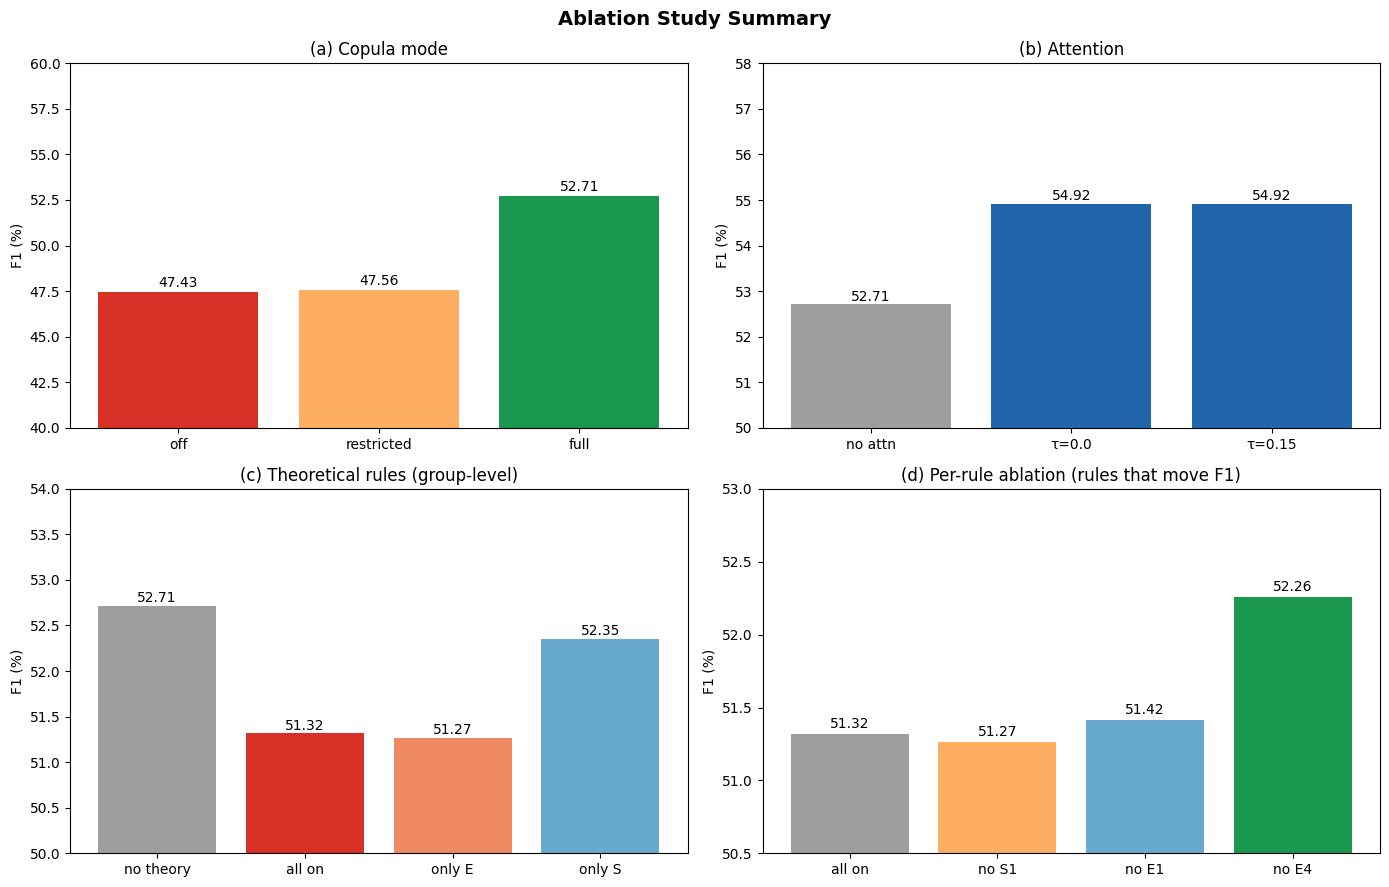

Gráfico salvo em: /home/ricardo/doutorado/extrator/v15/ablation_experiments/ablation_summary.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Ablation Study Summary", fontsize=14, fontweight="bold")

base_f1 = float(idx.loc["rq1_baseline_ud_puro", "f1"]) * 100

# (a) Cópula
ax = axes[0, 0]
k = ["rq2_cop_off", "rq2_cop_restricted", "rq2_cop_full"]
labels = ["off", "restricted", "full"]
vals = [idx.loc[x, "f1"]*100 for x in k]
ax.bar(labels, vals, color=["#d73027","#fdae61","#1a9850"])
ax.set_title("(a) Copula mode")
ax.set_ylabel("F1 (%)")
ax.set_ylim(40, 60)
for i,v in enumerate(vals):
    ax.text(i, v+0.3, f"{v:.2f}", ha="center", fontsize=10)

# (b) Atenção
ax = axes[0, 1]
k = ["rq1_baseline_ud_puro", "rq3_attn_on_thr0", "rq3_attn_on_thr15"]
labels = ["no attn", "τ=0.0", "τ=0.15"]
vals = [idx.loc[x, "f1"]*100 for x in k]
ax.bar(labels, vals, color=["#9e9e9e","#2166ac","#2166ac"])
ax.set_title("(b) Attention")
ax.set_ylabel("F1 (%)")
ax.set_ylim(50, 58)
for i,v in enumerate(vals):
    ax.text(i, v+0.08, f"{v:.2f}", ha="center", fontsize=10)

# (c) Teoria
ax = axes[1, 0]
k = ["rq1_baseline_ud_puro", "rq4_theory_all_on", "rq5_only_E", "rq5_only_S"]
labels = ["no theory", "all on", "only E", "only S"]
vals = [idx.loc[x, "f1"]*100 for x in k]
ax.bar(labels, vals, color=["#9e9e9e","#d73027","#ef8a62","#67a9cf"])
ax.set_title("(c) Theoretical rules (group-level)")
ax.set_ylabel("F1 (%)")
ax.set_ylim(50, 54)
for i,v in enumerate(vals):
    ax.text(i, v+0.04, f"{v:.2f}", ha="center", fontsize=10)

# (d) Regras com efeito
ax = axes[1, 1]
k = ["rq4_theory_all_on", "rq6_no_S1", "rq6b_no_E1", "rq6b_no_E4"]
labels = ["all on", "no S1", "no E1", "no E4"]
vals = [idx.loc[x, "f1"]*100 for x in k if x in idx.index]
ax.bar(labels[:len(vals)], vals, color=["#9e9e9e","#fdae61","#67a9cf","#1a9850"])
ax.set_title("(d) Per-rule ablation (rules that move F1)")
ax.set_ylabel("F1 (%)")
ax.set_ylim(50.5, 53)
for i,v in enumerate(vals):
    ax.text(i, v+0.04, f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
out_png = OUT_BASE / "ablation_summary.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {out_png.resolve()}")

In [26]:
import json
path = f"./ablation_experiments/abl_rq4_theory_all_on/bia_abl_rq4_theory_all_on_predictions_enriched.jsonl"
with open(path) as f:
    first_record = json.loads(f.readline())
first_pred = first_record['pred'][0] if first_record.get('pred') else None
if first_pred and 'heuristics_used' in first_pred:
    print("OK: patched fields presentes.")
    print(f"Exemplo: {first_pred['heuristics_used']}")
else:
    print("AINDA sem os campos do patched — algo falhou.")

OK: patched fields presentes.
Exemplo: ['apply_theoretical_rules', 'arg1_head:NOUN', 'arg2_head:PROPN', 'factuality:asserted', 'pattern_ud:verb+obj', 'source_rule:verb+obj', 'theory_mode:filter', 'variant_type:base']


In [27]:
import json

for label in ["rq3_attn_on_thr0", "rq4_theory_all_on"]:
    path = f"./ablation_experiments/abl_{label}/bia_abl_{label}_predictions_enriched.jsonl"
    with open(path) as f:
        first = json.loads(f.readline())
    preds = first.get('pred', [])
    if not preds:
        print(f"{label}: SEM triplas no primeiro registro, tenta próximo...")
        continue
    p = preds[0]
    has_patched = 'heuristics_used' in p
    has_theory_passed = 'theory_rules_passed' in p
    print(f"{label}:")
    print(f"  heuristics_used presente: {has_patched}")
    print(f"  theory_rules_passed presente: {has_theory_passed}")
    if has_patched:
        print(f"  exemplo heuristics_used: {p['heuristics_used'][:3]}...")

rq3_attn_on_thr0:
  heuristics_used presente: True
  theory_rules_passed presente: True
  exemplo heuristics_used: ['arg1_head:OTHER', 'arg2_head:OTHER', 'attention_enabled']...
rq4_theory_all_on:
  heuristics_used presente: True
  theory_rules_passed presente: True
  exemplo heuristics_used: ['apply_theoretical_rules', 'arg1_head:NOUN', 'arg2_head:PROPN']...


In [28]:
import json

for label in ["rq3_attn_on_thr0", "rq4_theory_all_on"]:
    path = f"./ablation_experiments/abl_{label}/bia_abl_{label}_predictions_enriched.jsonl"
    with open(path) as f:
        # pega a primeira tripla de qualquer registro que tenha preds
        first_pred = None
        for line in f:
            rec = json.loads(line)
            preds = rec.get('pred', [])
            if preds:
                first_pred = preds[0]
                break
    if first_pred:
        has_patched = 'heuristics_used' in first_pred
        print(f"{label}: heuristics_used presente = {has_patched}")
        if has_patched:
            print(f"  exemplo: {first_pred['heuristics_used'][:4]}...")
    else:
        print(f"{label}: nenhuma tripla encontrada")

rq3_attn_on_thr0: heuristics_used presente = True
  exemplo: ['arg1_head:OTHER', 'arg2_head:OTHER', 'attention_enabled', 'attn_threshold:0.0']...
rq4_theory_all_on: heuristics_used presente = True
  exemplo: ['apply_theoretical_rules', 'arg1_head:NOUN', 'arg2_head:PROPN', 'factuality:asserted']...
